# অধ্যায় ৫: মডেল মূল্যায়ন
## পাঠ ৫.১: ক্রস-ভ্যালিডেশন

আজ আমরা শিখব কীভাবে আমাদের মডেলকে সঠিকভাবে মূল্যায়ন করা যায়। একবার ট্রেন-টেস্ট স্প্লিট করে মডেল পরীক্ষা করা যথেষ্ট নয়—ক্রস-ভ্যালিডেশন কেন গুরুত্বপূর্ণ, সেটাই আজকের বিষয়।

### A. গল্প: পরীক্ষার খাতা

তুমি একটি ক্লাসের ছাত্র। তুমি একটি পরীক্ষা দিয়েছ। ধরো, পরীক্ষায় শুধু ১টি প্রশ্ন ছিল, আর সেটা তোমার পড়া একটি টপিক থেকে এসেছে। তুমি ভালো করেছ। কিন্তু এটা কি প্রমাণ করে যে তুমি পুরো সিলেবাস ভালোভাবে বুঝেছ? না।

যদি পরীক্ষায় ১০টি ভিন্ন টপিক থেকে প্রশ্ন থাকে, তাহলে তোমার নম্বর বেশি বিশ্বাসযোগ্য হবে।

ক্রস-ভ্যালিডেশন ঠিক এটাই করে—একবার নয়, ভিন্ন ভিন্ন ডেটার সেটে মডেলকে পরীক্ষা করে।

### B. সিঙ্গেল ট্রেন-টেস্ট স্প্লিটের সমস্যা

আমরা সাধারণত ডেটাকে ৭০-৩০ বা ৮০-২০ অনুপাতে ভাগ করি। কিন্তু সমস্যা হলো:
- যদি ভাগ্যক্রমে টেস্ট সেটে সহজ নমুনা চলে আসে, Accuracy বেশি দেখাবে
- যদি টেস্ট সেটে কঠিন নমুনা চলে আসে, Accuracy কম দেখাবে
- অর্থাৎ, একবারের ভাগ্যের ওপর মডেলের মূল্যায়ন নির্ভর করে না—এটা নির্ভরযোগ্য নয়

**ক্রস-ভ্যালিডেশন সমাধান:** ডেটাকে K ভাগে ভাগ করে, প্রতিবার একটি ভাগ টেস্ট, বাকি K-১ ভাগ ট্রেন হিসেবে ব্যবহার করো। কাজেই মডেলটি K বার টেস্ট হয়, এবং আমরা গড় স্কোর নিই।

In [1]:
# প্রয়োজনীয় লাইব্রেরি
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# ডেটা লোড করি
iris = load_iris()
X, y = iris.data, iris.target
print('Iris ডেটাসেট: ', X.shape[0], 'টি নমুনা,', X.shape[1], 'টি ফিচার')

Iris ডেটাসেট:  150 টি নমুনা, 4 টি ফিচার


### C. সিঙ্গেল স্প্লিটের ভ্যারিয়েন্স দেখা

আমরা ২০ বার আলাদা আলাদাভাবে ট্রেন-টেস্ট স্প্লিট করব এবং দেখব প্রতিবার Accuracy কতটা পরিবর্তিত হয়।

20 বার সিঙ্গেল স্প্লিটের ফলাফল:
  সর্বনিম্ন: 0.933
  সর্বোচ্চ: 1.000
  গড়: 0.967
  স্ট্যান্ডার্ড ডেভিয়েশন: 0.020


C:\Users\hp\AppData\Local\Temp\ipykernel_15308\661026335.py:29: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_15308\661026335.py:29: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_15308\661026335.py:29: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_15308\661026335.py:29: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_15308\661026335.py:29: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_15308\661026335.py:29: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\U

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2465 (\N{BENGALI LETTER DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2492 (\N{BENGALI SIGN NUKTA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


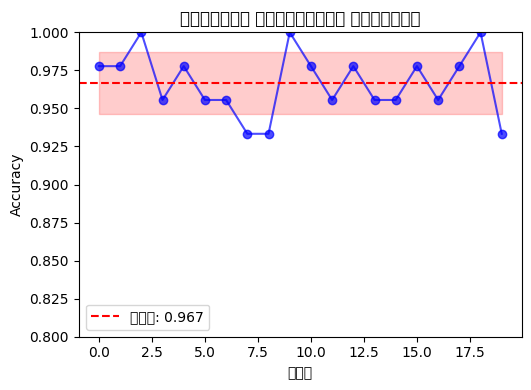

In [2]:
# 20 বার ভিন্ন ট্রেন-টেস্ট স্প্লিট
scores_single = []
for i in range(20):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=i
    )
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train, y_train)
    scores_single.append(knn.score(X_test, y_test))
print('20 বার সিঙ্গেল স্প্লিটের ফলাফল:')
print(f'  সর্বনিম্ন: {min(scores_single):.3f}')
print(f'  সর্বোচ্চ: {max(scores_single):.3f}')
print(f'  গড়: {np.mean(scores_single):.3f}')
print(f'  স্ট্যান্ডার্ড ডেভিয়েশন: {np.std(scores_single):.3f}')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(20), scores_single, 'bo-', alpha=0.7)
plt.axhline(y=np.mean(scores_single), color='r', linestyle='--', label=f'গড়: {np.mean(scores_single):.3f}')
plt.fill_between(range(20), 
                 np.mean(scores_single) - np.std(scores_single),
                 np.mean(scores_single) + np.std(scores_single),
                 alpha=0.2, color='r')
plt.xlabel('বার')
plt.ylabel('Accuracy')
plt.title('সিঙ্গেল স্প্লিটের তারতম্য')
plt.ylim(0.8, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

### D. K-Fold ক্রস-ভ্যালিডেশন

K-Fold ক্রস-ভ্যালিডেশনে আমরা ডেটাকে K সমান ভাগে ভাগ করি। K সাধারণত ৫ বা ১০ হয়।

**কাজের পদ্ধতি:**
- ১ম ধাপ: ভাগ ১ টেস্ট, বাকি ৪ ভাগ ট্রেন
- ২য় ধাপ: ভাগ ২ টেস্ট, বাকি ৪ ভাগ ট্রেন
- ...
- ৫ম ধাপ: ভাগ ৫ টেস্ট, বাকি ৪ ভাগ ট্রেন

প্রতিবার স্কোর বের করি, শেষে গড় এবং স্ট্যান্ডার্ড ডেভিয়েশন দেখি।

In [3]:
# 5-Fold ক্রস-ভ্যালিডেশন
knn = KNeighborsClassifier(n_neighbors=3)
cv_scores = cross_val_score(knn, X, y, cv=5)
print('5-Fold ক্রস-ভ্যালিডেশন ফলাফল:')
for i, score in enumerate(cv_scores):
    print(f'  Fold {i+1}: {score:.3f}')
print(f'\n  গড়: {np.mean(cv_scores):.3f}')
print(f'  স্ট্যান্ডার্ড ডেভিয়েশন: {np.std(cv_scores):.3f}')
print(f'\n→ ক্রস-ভ্যালিডেশনের ভ্যারিয়েন্স ({np.std(cv_scores):.3f}) সিঙ্গেল স্প্লিটের ({np.std(scores_single):.3f}) চেয়ে অনেক কম!')

5-Fold ক্রস-ভ্যালিডেশন ফলাফল:
  Fold 1: 0.967
  Fold 2: 0.967
  Fold 3: 0.933
  Fold 4: 0.967
  Fold 5: 1.000

  গড়: 0.967
  স্ট্যান্ডার্ড ডেভিয়েশন: 0.021

→ ক্রস-ভ্যালিডেশনের ভ্যারিয়েন্স (0.021) সিঙ্গেল স্প্লিটের (0.020) চেয়ে অনেক কম!


### E. StratifiedKFold

K-Fold-এর একটি সমস্যা আছে। ধরো, তোমার ডেটাসেটে ৯০% 'হ্যাঁ' এবং ১০% 'না'। K-Fold নিশ্চিত করতে পারে না যে প্রতিটি ফোল্ডে 'হ্যাঁ' ও 'না'-এর অনুপাত একই থাকবে। কোন ফোল্ডে হয়তো সব 'হ্যাঁ' চলে যেতে পারে!

StratifiedKFold এই সমস্যার সমাধান করে। এটি প্রতিটি ফোল্ডে মূল ডেটাসেটের ক্লাস অনুপাত সমান রাখে। অর্থাৎ, যদি ডেটাসেটে ৯০% 'হ্যাঁ' থাকে, প্রতিটি ফোল্ডেও ৯০% 'হ্যাঁ' থাকবে।

**কখন ব্যবহার করব?**
- ইমব্যালেন্সড ডেটাসেটের জন্য StratifiedKFold খুবই গুরুত্বপূর্ণ
- ক্লাসিফিকেশন প্রবলেমে সবসময় StratifiedKFold ব্যবহার করা ভালো

In [4]:
# StratifiedKFold বনাম সাধারণ KFold
from sklearn.datasets import make_classification

# ইমব্যালেন্সড ডেটাসেট তৈরি করি
X_imb, y_imb = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, weights=[0.9, 0.1], random_state=42
)
print('ইমব্যালেন্সড ডেটাসেট:')
print(f'  ক্লাস 0: {np.sum(y_imb == 0)} ({np.mean(y_imb == 0)*100:.1f}%)')
print(f'  ক্লাস 1: {np.sum(y_imb == 1)} ({np.mean(y_imb == 1)*100:.1f}%)')

# KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print('\nK Fold - প্রতিটি ফোল্ডে ক্লাস 1 এর সংখ্যা:')
for i, (train_idx, test_idx) in enumerate(kf.split(X_imb, y_imb)):
    print(f'  Fold {i+1}: {np.sum(y_imb[test_idx] == 1)}')

# StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('\nStratified K Fold - প্রতিটি ফোল্ডে ক্লাস 1 এর সংখ্যা:')
for i, (train_idx, test_idx) in enumerate(skf.split(X_imb, y_imb)):
    print(f'  Fold {i+1}: {np.sum(y_imb[test_idx] == 1)}')

ইমব্যালেন্সড ডেটাসেট:
  ক্লাস 0: 180 (90.0%)
  ক্লাস 1: 20 (10.0%)

K Fold - প্রতিটি ফোল্ডে ক্লাস 1 এর সংখ্যা:
  Fold 1: 3
  Fold 2: 2
  Fold 3: 4
  Fold 4: 5
  Fold 5: 6

Stratified K Fold - প্রতিটি ফোল্ডে ক্লাস 1 এর সংখ্যা:
  Fold 1: 4
  Fold 2: 4
  Fold 3: 4
  Fold 4: 4
  Fold 5: 4


### F. cross_val_score-এর অন্যান্য গুরুত্বপূর্ণ প্যারামিটার

**scoring:** আমরা Accuracy ছাড়াও অন্য মেট্রিক ব্যবহার করতে পারি। যেমন `scoring='f1'`, `scoring='precision'` ইত্যাদি।

**cv:** শুধু সংখ্যা (৫) না দিয়ে আমরা একটি CV ইটারেটর দিতে পারি। যেমন `cv=StratifiedKFold(5)`

**n_jobs:** `n_jobs=-1` দিলে কম্পিউটারের সব কোর ব্যবহার করে প্যারালালে কাজ করে, যা অনেক দ্রুত।

In [5]:
# cross_val_score-এর বিভিন্ন অপশন দেখা
knn = KNeighborsClassifier(n_neighbors=5)

# একাধিক মেট্রিকের জন্য cross_val_score
for scoring in ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']:
    scores = cross_val_score(
        knn, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring=scoring
    )
print(f'{scoring:20s}: {np.mean(scores):.3f} (+/- {np.std(scores):.3f})')

recall_macro        : 0.967 (+/- 0.030)


### G. ক্রস-ভ্যালিডেশনের সুবিধা ও অসুবিধা

**সুবিধা:**
✅ মডেলের পারফরম্যান্সের আরও নির্ভরযোগ্য অনুমান পাওয়া যায়
✅ ভ্যারিয়েন্স কমে যায়
✅ সব ডেটা ট্রেনিং এবং টেস্টিং উভয় কাজেই ব্যবহৃত হয়
✅ ইমব্যালেন্সড ডেটার জন্যও ভালো (StratifiedKFold দিয়ে)

**অসুবিধা:**
❌ K বার মডেল ট্রেইন করতে হয়, তাই সময় বেশি লাগে
❌ খুব বড় ডেটাসেটের জন্য ব্যয়বহুল হতে পারে

K-এর মান সাধারণত ৫ বা ১০ রাখা হয়। খুব ছোট ডেটাসেটের জন্য K বড় (যেমন ১০) এবং বড় ডেটাসেটের জন্য K ছোট (যেমন ৫) রাখা ভালো।

### H. তুমি কি বুঝতে পেরেছ?

**প্রশ্ন ১:** কেন সিঙ্গেল ট্রেন-টেস্ট স্প্লিট নির্ভরযোগ্য নয়?

**প্রশ্ন ২:** K-Fold ক্রস-ভ্যালিডেশন কীভাবে কাজ করে?

**প্রশ্ন ৩:** StratifiedKFold এবং KFold-এর মধ্যে পার্থক্য কী?

**প্রশ্ন ৪:** ক্রস-ভ্যালিডেশনের একটি সুবিধা এবং একটি অসুবিধা বলো।

### I. সারসংক্ষেপ

আজ আমরা শিখলাম:
✅ সিঙ্গেল স্প্লিটে ডেটা ভাগের ওপর Accuracy নির্ভর করে—এটা নির্ভরযোগ্য নয়
✅ K-Fold ক্রস-ভ্যালিডেশন ডেটাকে K ভাগে ভাগ করে K বার মডেল পরীক্ষা করে
✅ StratifiedKFold ক্লাস অনুপাত সমান রাখে—ইমব্যালেন্সড ডেটার জন্য দরকারি
✅ cross_val_score দিয়ে সহজেই ক্রস-ভ্যালিডেশন করা যায়
✅ ক্রস-ভ্যালিডেশন ভ্যারিয়েন্স কমায় এবং নির্ভরযোগ্য মূল্যায়ন দেয়

পরবর্তী পাঠে আমরা গ্রিড সার্চ শিখব—কীভাবে স্বয়ংক্রিয়ভাবে সেরা প্যারামিটার খুঁজে বের করা যায়!